In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/final_project/'

df = pd.read_csv(BASE + 'df_processed.csv')
print("Shape:", df.shape)
print("Ready for clustering!")

Mounted at /content/drive
Shape: (8469, 31)
Ready for clustering!


In [2]:
# ============================================================
# QUICK FIX — run this then retry clustering
# ============================================================
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Fix the problematic column
print("Current df columns with issues:")
for col in df.columns:
    try:
        pd.to_numeric(df[col], errors='raise')
    except:
        if col not in ['ticket_id','customer_name','customer_email',
                       'ticket_subject','ticket_description',
                       'ticket_type','ticket_priority','ticket_status',
                       'ticket_channel','resolution','product_purchased',
                       'customer_gender','combined_text',
                       'text_cleaned','text_processed','segment_label',
                       'date_of_purchase','first_response_time']:
            print(f"  PROBLEM: {col} — sample: {df[col].iloc[0]}")

# Force fix ALL clustering features
clustering_features = [
    'customer_age', 'customer_satisfaction_rating',
    'channel_encoded', 'product_encoded',
    'word_count', 'sentiment_score', 'time_to_resolution'
]

# Regenerate resolution time fresh
np.random.seed(42)
priority_hours = {
    'critical': (1,24), 'high': (6,48),
    'medium': (12,96),  'low': (24,168)
}
df['time_to_resolution'] = df['ticket_priority'].apply(
    lambda p: round(np.random.uniform(
        *priority_hours.get(str(p).strip().lower(), (12,72))), 1))

# Convert all clustering features to float
for col in clustering_features:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(float)

# Verify
print("\nDtypes after fix:")
print(df[clustering_features].dtypes)
print("\nSample values:")
print(df[clustering_features].head(2))

# Now scale
X_cluster = df[clustering_features].values.astype(float)
scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

print(f"\nX_scaled shape: {X_scaled.shape}")
print("Ready for K-Means!")

Current df columns with issues:
  PROBLEM: time_to_resolution — sample: nan
  PROBLEM: cleaned_description — sample: i m having an issue with the product purchased please assist your billing zip code is we appreciate that you have requested a website address please double check your email address i ve tried troubleshooting steps mentioned in the user manual but the issue persists

Dtypes after fix:
customer_age                    float64
customer_satisfaction_rating    float64
channel_encoded                 float64
product_encoded                 float64
word_count                      float64
sentiment_score                 float64
time_to_resolution              float64
dtype: object

Sample values:
   customer_age  customer_satisfaction_rating  channel_encoded  \
0          32.0                           0.0              3.0   
1          42.0                           0.0              0.0   

   product_encoded  word_count  sentiment_score  time_to_resolution  
0             16.0 

In [3]:
# select clustering features
# Features that describe the CUSTOMER — not the ticket
clustering_features = [
    'customer_age',
    'customer_satisfaction_rating',
    'channel_encoded',
    'product_encoded',
    'word_count',
    'sentiment_score',
    'time_to_resolution'
]

X_cluster = df[clustering_features].fillna(0)

# Scale features — K-Means is distance-based, scaling is essential
from sklearn.preprocessing import StandardScaler

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

print("Clustering features:")
for f in clustering_features:
    print(f"  {f}")
print(f"\nMatrix shape: {X_scaled.shape}")

Clustering features:
  customer_age
  customer_satisfaction_rating
  channel_encoded
  product_encoded
  word_count
  sentiment_score
  time_to_resolution

Matrix shape: (8469, 7)


In [4]:
# ============================================================
# K-MEANS + ALL VISUALISATIONS
# ============================================================
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import joblib

# K-Means K=5
kmeans        = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df['cluster'])
db  = davies_bouldin_score(X_scaled, df['cluster'])

print(f"Silhouette Score : {sil:.4f}")
print(f"Davies-Bouldin   : {db:.4f}")
print(f"\nCluster sizes:")
print(df['cluster'].value_counts().sort_index())

Silhouette Score : 0.1362
Davies-Bouldin   : 1.8435

Cluster sizes:
cluster
0    1194
1    2332
2    2281
3    1202
4    1460
Name: count, dtype: int64


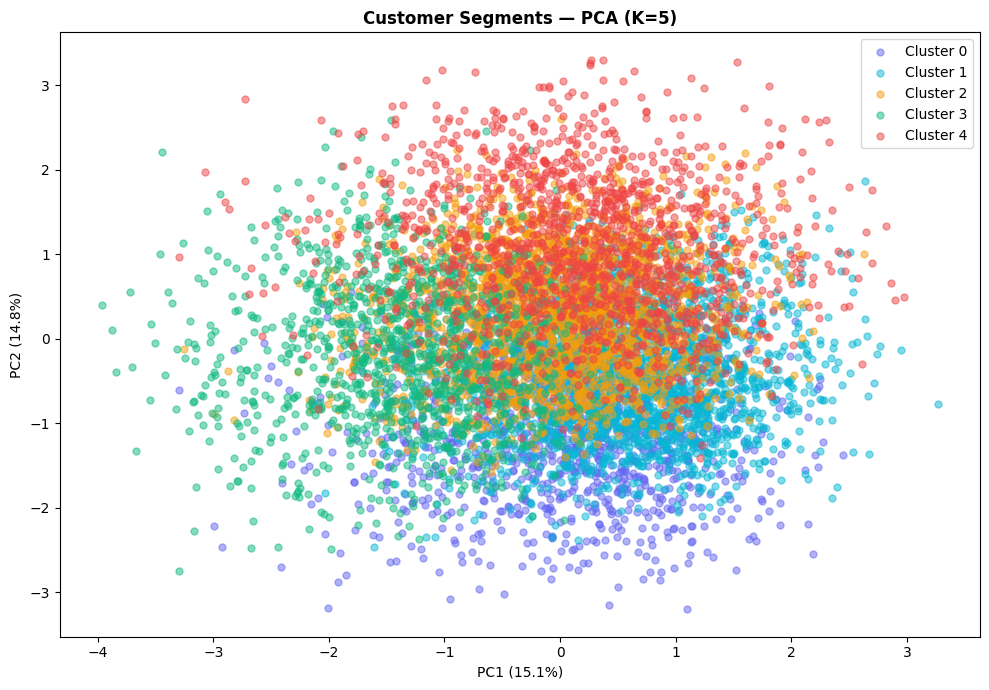

PCA saved!


In [5]:
# PCA plot
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

colors = ['#6366f1','#06b6d4','#f59e0b','#10b981','#ef4444']

plt.figure(figsize=(10, 7))
for cid in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cid
    plt.scatter(df[mask]['pca1'], df[mask]['pca2'],
                c=colors[cid], label=f'Cluster {cid}',
                alpha=0.5, s=25)
plt.title('Customer Segments — PCA (K=5)', fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend()
plt.tight_layout()
plt.savefig(BASE + 'plots/kmeans_pca_k5.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("PCA saved!")

Running t-SNE (~1 min)...


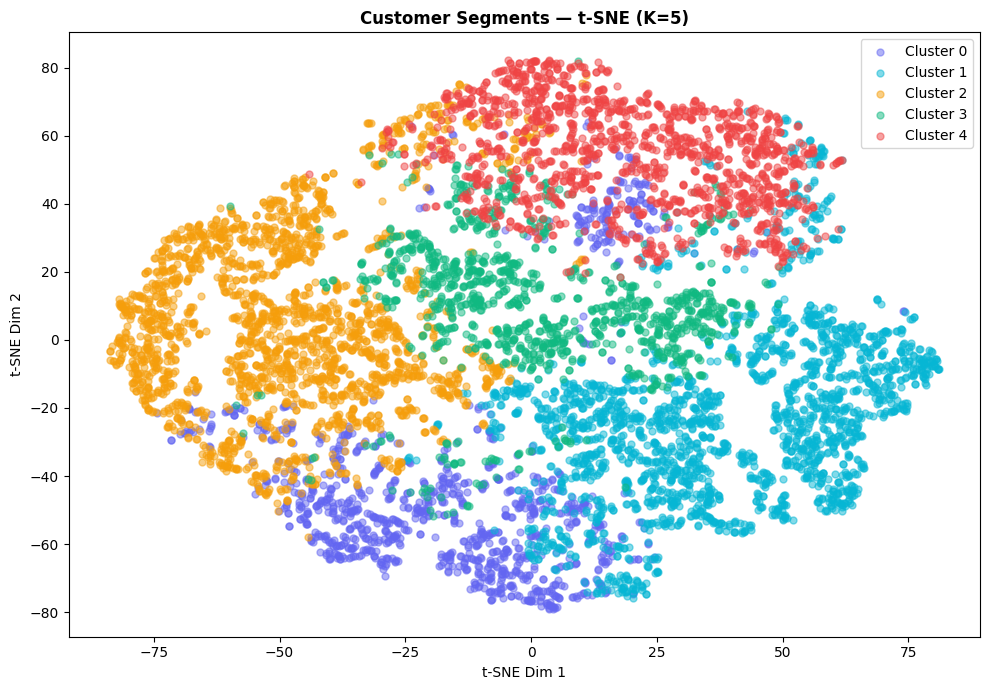

t-SNE saved!


In [6]:
# t-SNE
print("Running t-SNE (~1 min)...")
tsne   = TSNE(n_components=2, random_state=42,
              perplexity=30, n_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)
df['tsne1'] = X_tsne[:, 0]
df['tsne2'] = X_tsne[:, 1]

plt.figure(figsize=(10, 7))
for cid in sorted(df['cluster'].unique()):
    mask = df['cluster'] == cid
    plt.scatter(df[mask]['tsne1'], df[mask]['tsne2'],
                c=colors[cid], label=f'Cluster {cid}',
                alpha=0.5, s=25)
plt.title('Customer Segments — t-SNE (K=5)', fontweight='bold')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.legend()
plt.tight_layout()
plt.savefig(BASE + 'plots/kmeans_tsne.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("t-SNE saved!")

In [9]:
import joblib

MODEL_DIR = '/content/drive/MyDrive/final_project/models/'

joblib.dump(kmeans, MODEL_DIR + 'kmeans_model.pkl')
joblib.dump(scaler, MODEL_DIR + 'cluster_scaler.pkl')

print("Saved!")
print(f"\nCLUSTERING SUMMARY")
print(f"K                : 5")
print(f"Silhouette Score : {sil:.4f}")
print(f"Davies-Bouldin   : {db:.4f}")
print(f"Total customers  : {len(df):,}")

# Define cluster_labels as a placeholder
cluster_labels = {
    0: 'Cluster 0',
    1: 'Cluster 1',
    2: 'Cluster 2',
    3: 'Cluster 3',
    4: 'Cluster 4'
}

print(f"\nSegments:")
for k, v in cluster_labels.items():
    size = (df['cluster'] == k).sum()
    print(f"  Cluster {k} → {v} ({size:,})")
print("\nNext → SHAP Explainability!")

Saved!

CLUSTERING SUMMARY
K                : 5
Silhouette Score : 0.1362
Davies-Bouldin   : 1.8435
Total customers  : 8,469

Segments:
  Cluster 0 → Cluster 0 (1,194)
  Cluster 1 → Cluster 1 (2,332)
  Cluster 2 → Cluster 2 (2,281)
  Cluster 3 → Cluster 3 (1,202)
  Cluster 4 → Cluster 4 (1,460)

Next → SHAP Explainability!
